In [62]:
import os
import re 
from langchain_groq import ChatGroq
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings.fastembed import FastEmbedEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langgraph.graph import StateGraph,END,START
from pydantic import BaseModel
from typing import List
from dotenv import load_dotenv
load_dotenv()



True

In [63]:
docs = PyPDFLoader("Machine_learning.pdf").load()

In [14]:
chunks = RecursiveCharacterTextSplitter(chunk_size=1000 , chunk_overlap=200).split_documents(docs)

for d in chunks:
    d.page_content = d.page_content.encode("utf-8","ignore").decode("utf-8","ignore")

In [15]:
len(chunks)

1121

In [16]:
# convert chunks into embeddings 
embeddings = FastEmbedEmbeddings(model="BAAI/bge-small-en-v1.5")

vector_store = FAISS.from_documents(chunks, embeddings)

In [20]:
vector_store.save_local("vectore_store")

In [21]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

## Query Search 

In [19]:
llm = ChatGroq(model="openai/gpt-oss-120b",api_key=os.getenv("GROQ_API_KEY"),temperature=0)

In [56]:
class State(BaseModel):
    query:str
    docs: List[Document]
    strips:List[str]
    kept_strips:List[str]
    refined_context:str
    answer:str

In [92]:
# retrieve node 
def retrieve(state:State):
    query = state.query

    return {
        "docs": retriever.invoke(query)
    }

# sentence -level Decomposer

def decompose_to_sentences(text: str) -> List[str]:
    # Extra whitespace (newlines, tabs, multiple spaces) ko single space bana do
    text = re.sub(r"\s+", " ", text).strip()

    # . ! ? ke baad space aaye to wahan se sentence split karo
    sentences = re.split(r"(?<=[.!?])\s+", text)

    # Chhote/faltu fragments (<= 20 chars) hata do
    return [s.strip() for s in sentences if len(s.strip()) > 20]


# Filter (llm judge)
class KeepOrDrop(BaseModel):
    keep:bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system","You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "query: {query}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)

# refinement Operation  

def refine(state:State) -> dict:
    query = state.query

    # combining retrieve docs into one context string
    context = "\n\n".join(d.page_content for d in state.docs).strip()

    # Decompose : context -> sentence strips
    strips = decompose_to_sentences(context)

    # Filter:Keep only relevant strips 
    kept: List[str] = []

    for s in strips:
        if filter_chain.invoke({"query":query, "sentence":s}).keep:
            kept.append(s)

    # recompose : glue kept strips back together (internal Knowledge)
    refined_context ="\n".join(kept).strip()

    return {
        "strips":strips,
        "kept_strips":kept,
        "refined_context":refined_context,
    }

In [93]:
prompt = ChatPromptTemplate.from_messages(
    [
       ("system", "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
        "if the bullets are empty or insufficient, say: 'I don't know based on the provided books."),
        
       ("human", "query: {query}\n\nrefined_Context:\n{refined_context}"),

    ]
)

In [94]:
def generate(state:State):
    output = (prompt|llm).invoke({"query":state.query, "refined_context":state.refined_context})

    return {
             "answer": output.content
            }


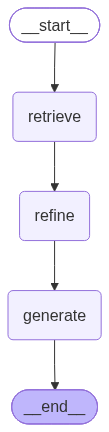

In [95]:
# ADD Graph 

graph = StateGraph(State)
graph.add_node("retrieve", retrieve)
graph.add_node("refine", refine)
graph.add_node("generate",generate)

graph.add_edge(START,"retrieve")
graph.add_edge("retrieve","refine")
graph.add_edge("refine", "generate")
graph.add_edge("generate",END)
app = graph.compile()

app

In [101]:
res = app.invoke({"query": "Explain the bias-variance tradeoff", "docs":[], "strips":[],"kept_strips":[],"refined_context": "", "answer":""})

print(res["answer"])

- Increasing the bias will decrease the variance, and increasing the variance will decrease the bias.  
- Parametric algorithms are generally seen to demonstrate **high bias but low variance**; non‑parametric algorithms demonstrate **low bias and high variance**.  
- The goal of supervised machine learning is to achieve a **balance between bias and variance**.  
- In k‑Nearest Neighbors (kNN), the user‑configurable parameter **k** can be used to trade off bias and variance.  
- **High bias** → low accuracy (predicted values are not close to the real value); this often leads to **underfitting**.  
- **High variance** → low prediction quality (predicted values are scattered); errors arise from differences in training data sets.  
- **Low bias** → high accuracy (predicted values are close to the real value).  
- **Low variance** → predictions are close to each other (high prediction consistency).


In [98]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)


complex and magnifies even small differences in the training
data.
As is quite understandable:
Increasing the bias will decrease the variance, and
Increasing the variance will decrease the bias
On one hand, parametric algorithms are generally seen to
demonstrate high bias but low variance. On the other hand,
non-parametric algorithms demonstrate low bias and high
variance.
As can be observed in Figure 3.6 , the best solution is to
have a model with low bias as well as low variance. However,
that may not be possible in reality. Hence, the goal of
supervised machine learning is to achieve a balance between
bias and variance. The learning algorithm chosen and the user
parameters which can be configured helps in striking a trade-
off between bias and variance. For example, in a popular
supervised algorithm k-Nearest Neighbors or kNN, the user
configurable parameter ‘k’ can be used to do a trade-off
between bias and variance. In one hand, when the value of ‘k’
******************************

In [99]:
for i, doc in enumerate(res["docs"]):
    print(f"--- Doc {i+1} ---")
    print(doc.page_content)
    print("*" * 100)

--- Doc 1 ---
complex and magnifies even small differences in the training
data.
As is quite understandable:
Increasing the bias will decrease the variance, and
Increasing the variance will decrease the bias
On one hand, parametric algorithms are generally seen to
demonstrate high bias but low variance. On the other hand,
non-parametric algorithms demonstrate low bias and high
variance.
As can be observed in Figure 3.6 , the best solution is to
have a model with low bias as well as low variance. However,
that may not be possible in reality. Hence, the goal of
supervised machine learning is to achieve a balance between
bias and variance. The learning algorithm chosen and the user
parameters which can be configured helps in striking a trade-
off between bias and variance. For example, in a popular
supervised algorithm k-Nearest Neighbors or kNN, the user
configurable parameter ‘k’ can be used to do a trade-off
between bias and variance. In one hand, when the value of ‘k’
****************